In [26]:
#part 1, import dataset, pengenalan parameter, analisa, visualisasi dll

import pandas as pd
import matplotlib.pyplot as plt


DL_DATASET_PATH = "D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL.xlsx"
UL_DATASET_PATH = "D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_UL.xlsx"

LONG = 'Longitude'
LAT = 'Latitude'

# list parameter di dataset, bisa dicari penjelasan nya, buat apa, apa pengaruh terhadap lokasi UE, apakah bisa ditambahkan sebagai paramter, dll.
PARAMETER_COLS = [
    'Longitude', 'Latitude',
    'Technology_Mode'
    , 'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0'

    ,'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_PCI_1', 'NR_UE_Nbr_PCI_2', 'NR_UE_Nbr_PCI_3', 'NR_UE_Nbr_PCI_4',
    'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRP_1', 'NR_UE_Nbr_RSRP_2', 'NR_UE_Nbr_RSRP_3', 'NR_UE_Nbr_RSRP_4',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRQ_2', 'NR_UE_Nbr_RSRQ_3', 'NR_UE_Nbr_RSRQ_4',

    'NR_UE_Timing_Advance',
    'NR_UE_Pathloss_DL_0',
    'NR_UE_Throughput_PDCP_DL',
    'App_Throughput_DL',
    'NR_UE_NACK_Rate_DL_0', 'NR_UE_Ack_As_Nack_DL_0',
    'NR_UE_MCS_DL_0', 'NR_UE_RB_Num_DL_0',
    'NR_UE_Modulation_Avg_DL_0',
    'NR_UE_RI_DL_0',
    'NR_UE_BLER_DL_0',
    'NR_UE_CCE_AggregationLev_0',
    'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_Power_Tx_PRACH_0',
    'NR_UE_NACK_Rate_UL_0',
    'NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RACH_Procedure_Count',
    'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCReEst_EndResult',
    'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnectionSetupOk', 'NR_UE_RRCConnectionComplete', 
    'NR_UE_RRCConnectionDrop', 'NR_UE_RRCHOAttempt', 'NR_UE_RRCHOOK',
    'NR_RRC_MsgType',
    'NAS_5GS_MM_MessageType',
    'NAS_5GS_SM_MessageType'
]



dl = pd.read_excel(DL_DATASET_PATH, sheet_name="Series_Formatted_Data")
# ul = pd.read_excel(UL_DATASET_PATH, sheet_name="Series_Formatted_Data")


In [ ]:
# 1. Hapus baris dengan NaN di kolom penting
# dl_clean = dl.dropna(subset=PARAMETER_NaN)
#parameter yang bisa dihapus jika NaN, cari tau mana yang bisa dihapus, mana yang perlu di isi blank
PARAMETER_NaN = [
    'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',

]
dl_clean = dl
print(f"{len(dl)}  {len(dl_clean)}")

72480  72480


Data dari baris 0 hingga 72480:


C:\Users\deeric\AppData\Local\Temp\ipykernel_16152\2345657368.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['NR_UE_PCI_0'] = subset['NR_UE_PCI_0'].fillna(0).astype(int)


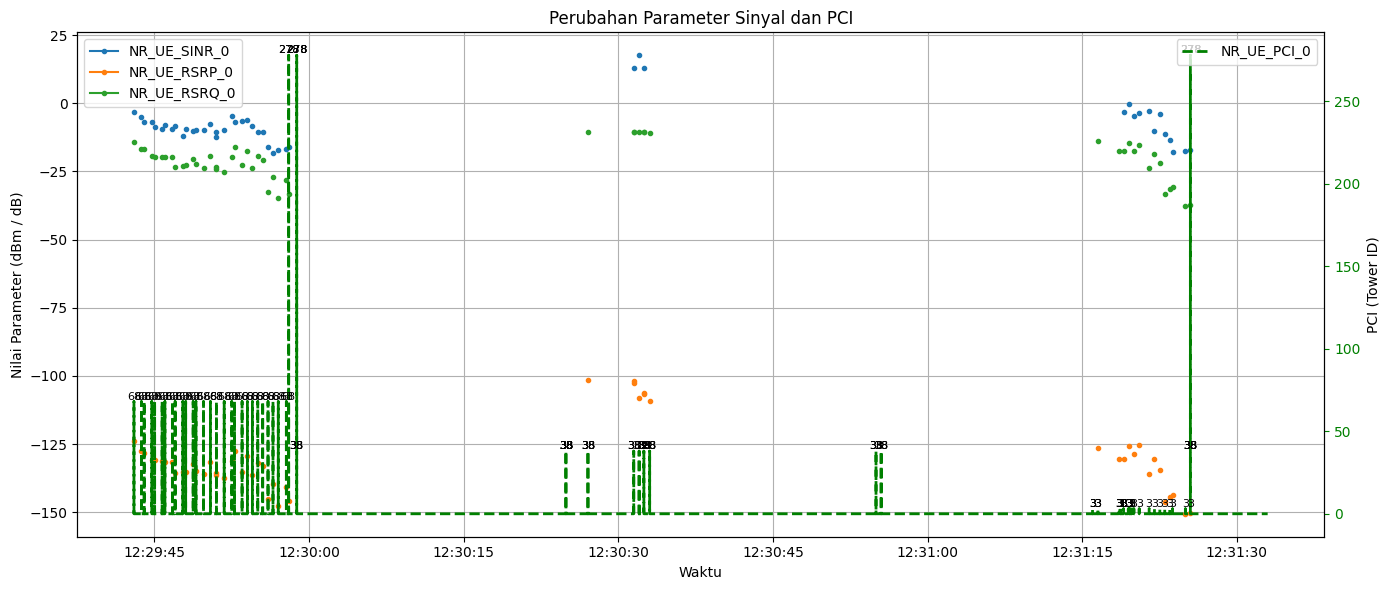

In [146]:

# tampilkan dari rentang index

# X = 0  # Ganti dengan indeks awal
# Y = len(dl_clean)  # Ganti dengan indeks akhir
# subset = dl_clean.iloc[X:Y+1]  # +1 karena slicing di Python eksklusif
# subset = dl.iloc[X:Y+1]


# Metode 2: Berdasarkan rentang nilai parameter (misal: NR_UE_RSRP_0 antara X dan Y)

# X = -150     # RSRP atas
# Y = -125  # RSRP bawah
# subset = dl_clean[(dl_clean['NR_UE_RSRP_0'] >= X) & (dl_clean['NR_UE_RSRP_0'] <= Y)]

# Metode 3: Berdasarkan rentang geografis (misal: Longitude antara X dan Y, Latitude bebas)

#29.025 29.035  41.103 41.095 # kasus posisi di ujung peta
long_min = 29.025
long_max = 29.035
lat_min = 41.095
lat_max = 41.103
subset = dl_clean[
    (dl_clean['Longitude'] >= long_min) & (dl_clean['Longitude'] <= long_max) &
    (dl_clean['Latitude'] >= lat_min) & (dl_clean['Latitude'] <= lat_max)
]


# Kolom yang ingin ditampilkan (sesuaikan dengan parameter yang relevan)
cols_to_print = ['Time', 'Latitude', 'Longitude', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0']

# Print data
print(f"Data dari baris {X} hingga {Y}:")
# print(subset[cols_to_print].to_string(index=False))

# Plot perubahan parameter
import matplotlib.pyplot as plt

# Parameter yang ingin diplot (sesuaikan dengan kebutuhan)
params_to_plot = ['NR_UE_SINR_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0']



# Plot utama: RSRP, RSRQ, SINR
fig, ax1 = plt.subplots(figsize=(14, 6))
for param in ['NR_UE_SINR_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0']:
    ax1.plot(subset['Time'], subset[param], label=param, marker='.')

ax1.set_xlabel('Waktu')
ax1.set_ylabel('Nilai Parameter (dBm / dB)')
ax1.set_title('Perubahan Parameter Sinyal dan PCI')
ax1.grid(True)
ax1.legend(loc='upper left')

# Tambahkan sumbu y kedua untuk PCI
ax2 = ax1.twinx()

# Ganti NaN di NR_UE_PCI_0 dengan 0 (atau gunakan pd.notna() untuk skip)
subset['NR_UE_PCI_0'] = subset['NR_UE_PCI_0'].fillna(0).astype(int)


# Plot PCI sebagai step plot
ax2.plot(subset['Time'], subset['NR_UE_PCI_0'], 
         label='NR_UE_PCI_0', color='green', linestyle='--', linewidth=2, drawstyle='steps-pre')

# Tambahkan label teks hanya untuk nilai PCI yang tidak NaN
for i, row in subset.iterrows():
    if row['NR_UE_PCI_0'] != 0:  # Skip label untuk placeholder 0
        ax2.text(
            row['Time'], 
            row['NR_UE_PCI_0'], 
            f"{row['NR_UE_PCI_0']}", 
            color='black', 
            fontsize=8, 
            ha='center', 
            va='bottom'
        )

# Kustomisasi sumbu y kedua
ax2.set_ylabel('PCI (Tower ID)')
ax2.tick_params(axis='y', colors='green')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



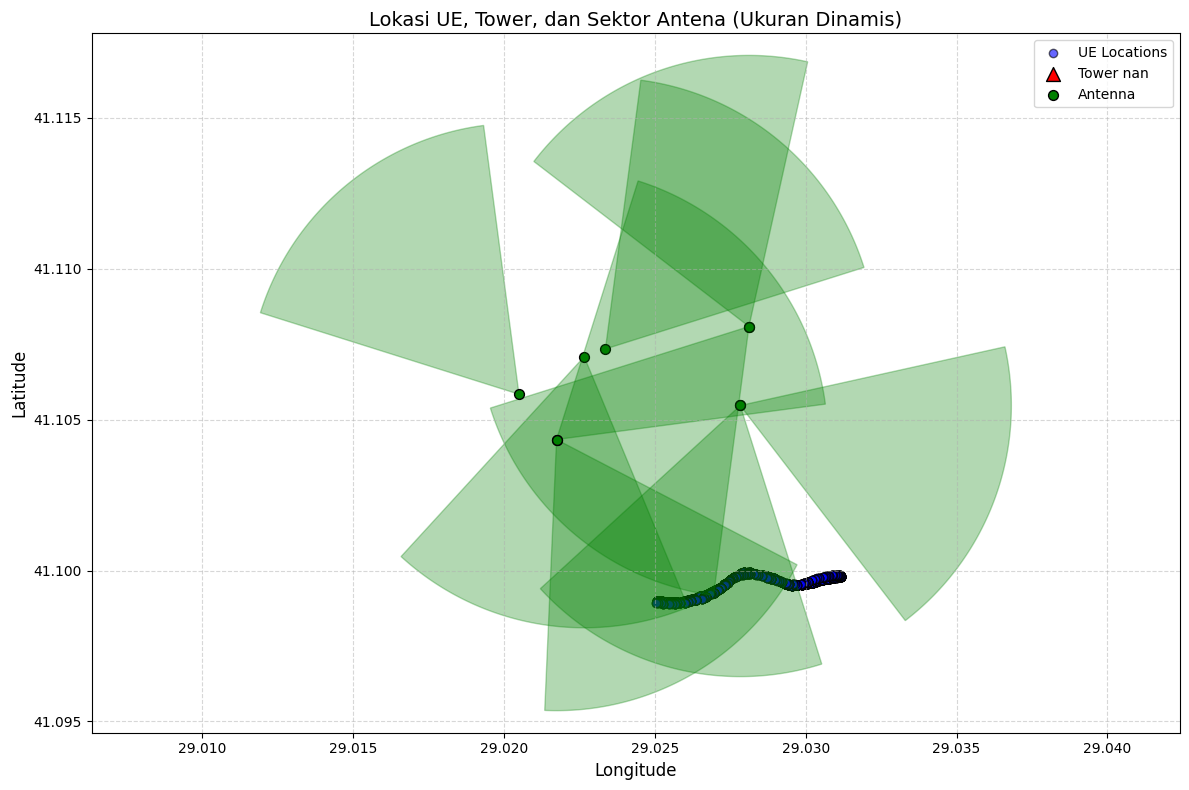

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Baca data dari Excel ---
antenna_df = pd.read_excel('D:/Kuliah-temp/Teknofest/program/dataset/config/antenna.xlsx')
max_diameter_m = 2000  # Pastikan kolom ini ada di Excel

# --- Pisahkan antena dan tower berdasarkan kolom Azimuth ---
antenna_data = antenna_df[antenna_df['Azimuth [°]'].notna()]
tower_data = antenna_df[antenna_df['Azimuth [°]'].isna()]

# --- Fungsi untuk membuat sektor antena dengan radius dinamis ---
def create_antenna_sector(lat, lon, azimuth, beamwidth, radius_deg, num_points=100):
    """
    radius_deg: Radius dalam derajat (hasil konversi dari meter)
    """
    start_angle = np.radians(azimuth - beamwidth / 2)
    end_angle = np.radians(azimuth + beamwidth / 2)
    angles = np.linspace(start_angle, end_angle, num_points)
    x = lon + radius_deg * np.cos(angles)
    y = lat + radius_deg * np.sin(angles)
    return np.column_stack((np.append(x, lon), np.append(y, lat)))

# --- Plot Data ---
plt.figure(figsize=(12, 8))

# Plot lokasi UE (subset data)
plt.scatter(
    subset['Longitude'], 
    subset['Latitude'], 
    c='blue', 
    alpha=0.6, 
    label='UE Locations', 
    edgecolor='k'
)

# Plot lokasi tower
for _, row in tower_data.iterrows():
    plt.scatter(
        row['Longitude'], 
        row['Latitude'], 
        c='red', 
        s=100, 
        label=f"Tower {row['Cell Name']}", 
        edgecolor='black', 
        marker='^'
    )
    plt.text(row['Longitude'], row['Latitude'], f" {row['Cell Name']}", fontsize=9, color='red')

# Plot lokasi antena dan sektornya
# plt.scatter(dl_clean['Longitude'], dl_clean['Latitude'], c='purple',alpha=0.05, label='trajectory')
for _, row in antenna_data.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    azimuth = row['Azimuth [°]']
    beamwidth = row['Horizontal Beamwidth [°]']
    
    # Konversi MAX_DIAMETER (meter) ke radius dalam derajat
    radius_deg = max_diameter_m / 2 / 111319.5  # 1 derajat ≈ 111,319.5 meter
    
    sector = create_antenna_sector(lat, lon, azimuth, beamwidth, radius_deg)
    plt.fill(sector[:, 0], sector[:, 1], color='green', alpha=0.3, edgecolor='green')
    plt.scatter(lon, lat, c='green', s=50, label='Antenna', edgecolor='black')

# --- Kustomisasi Plot ---
plt.title('Lokasi UE, Tower, dan Sektor Antena (Ukuran Dinamis)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Legenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.axis('equal')  # Skala X dan Y sama
plt.tight_layout()
plt.show()

AttributeError: module 'contextily' has no attribute 'add_basemap_background'

c:\Users\deeric\miniconda3\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\deeric\miniconda3\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\deeric\miniconda3\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\deeric\miniconda3\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\deeric\miniconda3\Lib\site-packages\cartopy\io\__i

<Figure size 1200x800 with 0 Axes>

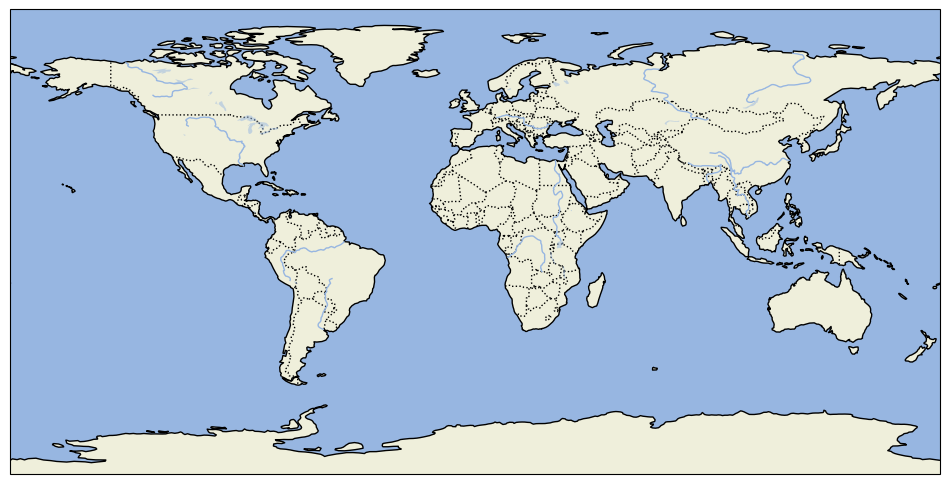

In [ ]:
#ini belum bisa, gatau tuh

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  # Proyeksi peta
import cartopy.feature as cfeature  # Fitur dasar peta
import contextily as ctx  # Untuk tile OpenStreetMap

# --- Baca data antena dan pisahkan antena & tower ---
antenna_df = pd.read_excel('D:/Kuliah-temp/Teknofest/program/dataset/config/antenna.xlsx')
antenna_data = antenna_df[antenna_df['Azimuth [°]'].notna()]
tower_data = antenna_df[antenna_df['Azimuth [°]'].isna()]

# --- Fungsi untuk membuat sektor antena ---
def create_antenna_sector(lat, lon, azimuth, beamwidth, radius_deg, num_points=100):
    start_angle = np.radians(azimuth - beamwidth / 2)
    end_angle = np.radians(azimuth + beamwidth / 2)
    angles = np.linspace(start_angle, end_angle, num_points)
    x = lon + radius_deg * np.cos(angles)
    y = lat + radius_deg * np.sin(angles)
    return np.column_stack((np.append(x, lon), np.append(y, lat)))

# --- Konversi MAX_DIAMETER ke derajat ---
max_diameter_m = 2000  # Radius maksimum pancaran dalam meter
radius_deg = max_diameter_m / 2 / 111319.5  # 1 derajat ≈ 111,319.5 meter

# --- Setup proyeksi peta (Mercator) ---
fig = plt.figure(figsize=(12, 8))
import cartopy.crs as ccrs

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())  # Gunakan objek proyeksi# fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': 'cartopy'})

# --- Tambahkan fitur dasar peta ---
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# --- Tambahkan tile OpenStreetMap ---
ctx.add_basemap_background(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# --- Plot lokasi UE (subset data) ---
ax.scatter(
    subset['Longitude'], 
    subset['Latitude'], 
    transform=ccrs.PlateCarree(),  # Koordinat dalam derajat
    c='blue', 
    alpha=0.6, 
    label='UE Locations', 
    edgecolor='k'
)

# --- Plot lokasi tower ---
for _, row in tower_data.iterrows():
    ax.scatter(
        row['Longitude'], 
        row['Latitude'], 
        transform=ccrs.PlateCarree(),
        c='red', 
        s=100, 
        label=f"Tower {row['Cell Name']}", 
        edgecolor='black', 
        marker='^'
    )
    ax.text(row['Longitude'], row['Latitude'], f" {row['Cell Name']}", 
            fontsize=9, color='red', transform=ccrs.PlateCarree())

# --- Plot lokasi antena dan sektornya ---
for _, row in antenna_data.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    azimuth = row['Azimuth [°]']
    beamwidth = row['Horizontal Beamwidth [°]']
    
    # Buat sektor antena
    sector = create_antenna_sector(lat, lon, azimuth, beamwidth, radius_deg)
    
    # Plot sektor
    ax.fill(sector[:, 0], sector[:, 1], 
            transform=ccrs.PlateCarree(), 
            color='green', alpha=0.3, edgecolor='green')
    
    # Plot titik antena
    ax.scatter(lon, lat, transform=ccrs.PlateCarree(), 
               c='green', s=50, label='Antenna', edgecolor='black')

# --- Set batas plot sesuai data ---
min_lon, max_lon = subset['Longitude'].min() - 0.005, subset['Longitude'].max() + 0.005
min_lat, max_lat = subset['Latitude'].min() - 0.005, subset['Latitude'].max() + 0.005
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# --- Kustomisasi Plot ---
plt.title('Lokasi UE, Tower, dan Sektor Antena dengan Peta', fontsize=14)
ax.gridlines(draw_labels=True)  # Tambahkan garis grid

# --- Legenda ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

In [ ]:
#FILTER DATA BUANG DUPLIKAT LONG LAT
dl["Longitude"] = pd.to_numeric(dl["Longitude"], errors='coerce')
dl["Latitude"] = pd.to_numeric(dl["Latitude"], errors='coerce')

dl.drop